## 01.분석 기본세팅 및 데이터 불러오기

In [64]:
from konlpy.tag import Okt
import pandas as pd
import re
from collections import Counter
from matplotlib import font_manager, rc
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import os

#   한글 폰트 설정
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# WordCloud 객체 생성
const_wc = WordCloud(font_path=font_path,
                     background_color='ivory')

#   해당 품사 확인
stnd_pos = ['Noun', 'Adjective', 'Verb']
#   불용어 처리
stop_words = ['정말', '진짜', '하는', '입니다', '정도', '진짜', '그냥', '있는', '봤어요']

In [65]:
path_001 = r'./data/'
file_001 = "daum_movie_review.csv"

file_path_001 = os.path.join(path_001,file_001)

#   데이터 불러오기
movie_review = pd.read_csv(file_path_001)

## 02.데이터 전처리

In [66]:
#   한글만 남기고
movie_review['set_review'] = movie_review["review"].str.replace("[^ㅏ-ㅣㄱ-ㅎ가-힣]+", " ", regex=True)

## 03.형태소 분석

In [67]:
tokenizer = Okt()
results = []

for text in movie_review['set_review']:
    tagged_tokens = tokenizer.pos(text)
    set_tokens = [word for word, tag in tagged_tokens
                  if tag in stnd_pos and 
                  word not in stop_words and
                  len(word) > 1]
    results.append(set_tokens)

movie_review['tokens']=results


## 04. 분석 결과 빈도 확인

In [73]:
#   개별 행 데이터 형태가 리스트니까, 
#   해당 행에서 리스트 꺼낸 후 개별 단어 꺼내기
all_token = [word for tokens in movie_review['tokens'] for word in tokens]
count_tokens = Counter(all_token)

#   확인하게 편하게
for item in count_tokens.most_common(20):
    print(item)

('영화', 6697)
('연기', 1293)
('감동', 1223)
('생각', 1027)
('배우', 847)
('사람', 819)
('스토리', 815)
('눈물', 737)
('시간', 721)
('보고', 713)
('최고', 682)
('재미', 641)
('마지막', 612)
('마동석', 557)
('광주', 531)
('윤계상', 517)
('기대', 516)
('내용', 494)
('장면', 438)
('원작', 422)


## 05.시각화

##### 1) 수평 막대 그래프

In [69]:
#   시각화 위해 전처리
x = [word for word, _ in count_tokens.most_common(20)]
y = [count for _, count in count_tokens.most_common(20)]


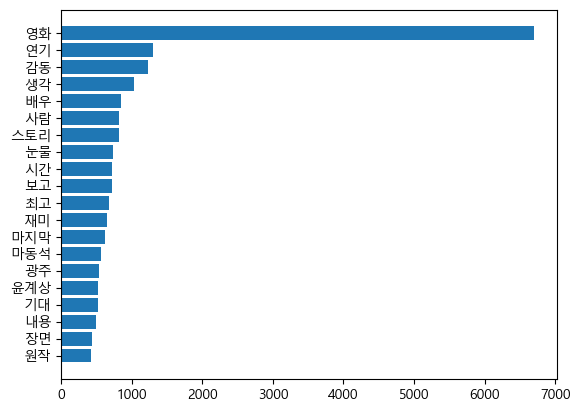

In [85]:
#   수평 막대 그래프 barh
#   [::-1]안하면 오름차순
plt.barh(x[::-1], y[::-1])

#   굳이 print() 안 해도
plt.show()


daum_movie_review.csv


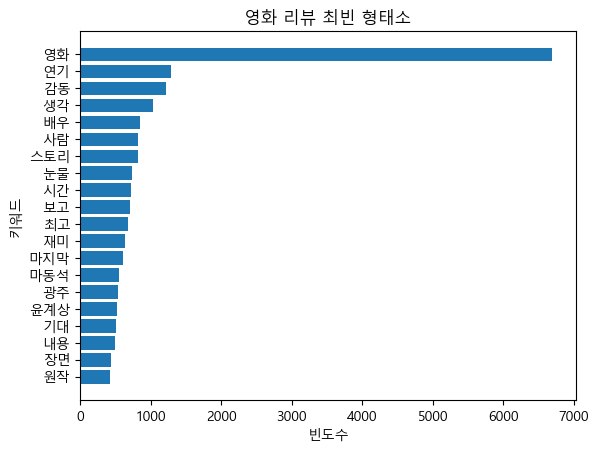

In [86]:
plt.barh(x[::-1], y[::-1])

#   추가 정보 기입
plt.title("영화 리뷰 최빈 형태소")
plt.xlabel('빈도수')
plt.ylabel('키워드')

# 파일 저장
print(file_001)
output_hbar = file_001.replace('.csv', '_bargraph.png')
plt.savefig(output_hbar)

##### 2) Word Cloud

[('영화', 6697), ('연기', 1293), ('감동', 1223), ('생각', 1027), ('배우', 847)]
{'영화': 6697, '연기': 1293, '감동': 1223, '생각': 1027, '배우': 847}


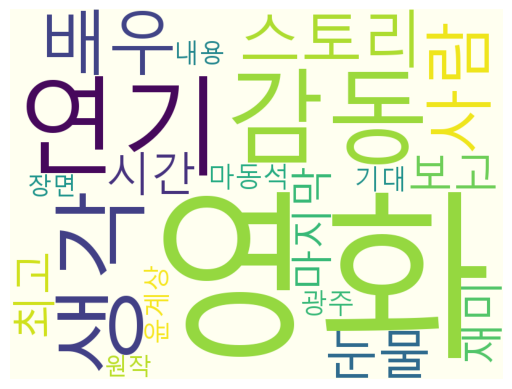

In [81]:
#   상위 20개 키워드
wc_tokens = WordCloud(font_path = font_path,
                      width = 800,
                      height = 600,
                      max_words = 50,
                      background_color = 'ivory'
                      )

print(count_tokens.most_common(5))
print(dict(count_tokens.most_common(5)))

#   상위 단어로 출력하려면 dict 처리!
wc_tokens = wc_tokens.generate_from_frequencies(dict(count_tokens.most_common(20)))
plt.imshow(wc_tokens)
plt.axis('off')
plt.show()

In [82]:
#   이미지 저장
wc_tokens.to_file(file_001.replace('.csv', '_wordcloud.png'))